# Meteo: Air temperature (TA) (2005-2024)

**Author**: Lukas Hörtnagl (holukas@ethz.ch)

# Variable

In [2]:
varname = 'TA_T1_2_1'
var = "TA"  # Name shown in plots
units = "°C"

# Imports

In [35]:
import importlib.metadata
import warnings
from datetime import datetime
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

import diive as dv
from diive.core.io.files import save_parquet, load_parquet
from diive.core.plotting.cumulative import CumulativeYear
from diive.core.plotting.bar import LongtermAnomaliesYear

warnings.filterwarnings(action='ignore', category=FutureWarning)
warnings.filterwarnings(action='ignore', category=UserWarning)
version_diive = importlib.metadata.version("diive")
print(f"diive version: v{version_diive}")

diive version: v0.87.0


# Load data

In [4]:
SOURCEDIR = r"../80_FINALIZE"
FILENAME = r"81.1_FLUXES_M15_MGMT_L4.2_NEE_GPP_RECO_LE_H_FN2O_FCH4.parquet"
FILEPATH = Path(SOURCEDIR) / FILENAME
df = load_parquet(filepath=FILEPATH)
df

Loaded .parquet file ..\80_FINALIZE\81.1_FLUXES_M15_MGMT_L4.2_NEE_GPP_RECO_LE_H_FN2O_FCH4.parquet (1.508 seconds).
    --> Detected time resolution of <30 * Minutes> / 30min 


,.PREC_RAIN_TOT_GF1_0.5_1_MEAN3H-12,.PREC_RAIN_TOT_GF1_0.5_1_MEAN3H-18,.PREC_RAIN_TOT_GF1_0.5_1_MEAN3H-24,.PREC_RAIN_TOT_GF1_0.5_1_MEAN3H-6,.SWC_GF1_0.15_1_gfXG_MEAN3H-12,.SWC_GF1_0.15_1_gfXG_MEAN3H-18,.SWC_GF1_0.15_1_gfXG_MEAN3H-24,.SWC_GF1_0.15_1_gfXG_MEAN3H-6,.TS_GF1_0.04_1_gfXG_MEAN3H-12,.TS_GF1_0.04_1_gfXG_MEAN3H-18,.TS_GF1_0.04_1_gfXG_MEAN3H-24,.TS_GF1_0.04_1_gfXG_MEAN3H-6,.TS_GF1_0.15_1_gfXG_MEAN3H-12,.TS_GF1_0.15_1_gfXG_MEAN3H-18,.TS_GF1_0.15_1_gfXG_MEAN3H-24,...,GPP_NT_CUT_50_gfRF,RECO_DT_CUT_50_gfRF,GPP_DT_CUT_50_gfRF,RECO_DT_CUT_50_gfRF_SD,GPP_DT_CUT_50_gfRF_SD,G_GF1_0.03_1,G_GF1_0.03_2,G_GF1_0.05_1,G_GF1_0.05_2,G_GF4_0.02_1,G_GF5_0.02_1,LW_OUT_T1_2_1,NETRAD_T1_2_1,PPFD_OUT_T1_2_2,SW_OUT_T1_2_1
TIMESTAMP_MIDDLE,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2005-01-01 00:15:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.918553,0.093071,0.0,0.080016,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2005-01-01 00:45:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.917972,0.092682,0.0,0.079688,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2005-01-01 01:15:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.163001,0.093071,0.0,0.080016,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2005-01-01 01:45:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.190890,0.093071,0.0,0.080016,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2005-01-01 02:15:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.167042,0.092295,0.0,0.079361,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-31 21:45:00,0.0,0.0,0.0,0.0,52.229004,52.226300,52.226689,52.216796,3.458828,3.150402,3.115260,3.660897,4.335667,4.347764,4.385967,...,-0.334996,1.091028,0.0,0.265808,0.0,NaN,NaN,-9.097370,-7.880106,NaN,NaN,311.167160,-5.883538,0.0,0.0
2024-12-31 22:15:00,0.0,0.0,0.0,0.0,52.227858,52.227986,52.224528,52.214211,3.522570,3.187638,3.103440,3.643396,4.338551,4.342880,4.379524,...,-0.310533,1.078751,0.0,0.264327,0.0,NaN,NaN,-9.561669,-8.172388,NaN,NaN,310.079817,-6.269816,0.0,0.0
2024-12-31 22:45:00,0.0,0.0,0.0,0.0,52.226640,52.229837,52.222456,52.209876,3.578745,3.230037,3.095339,3.624025,4.343767,4.339440,4.372636,...,-0.225651,1.079759,0.0,0.264447,0.0,NaN,NaN,-10.138718,-8.527732,NaN,NaN,309.604987,-6.934394,0.0,0.0


In [5]:
series = df[varname].copy()
series

TIMESTAMP_MIDDLE
2005-01-01 00:15:00    1.566667
2005-01-01 00:45:00    1.533333
2005-01-01 01:15:00    1.566667
2005-01-01 01:45:00    1.566667
2005-01-01 02:15:00    1.500000
                         ...   
2024-12-31 21:45:00   -1.919472
2024-12-31 22:15:00   -2.104678
2024-12-31 22:45:00   -2.089444
2024-12-31 23:15:00   -2.355761
2024-12-31 23:45:00   -2.578839
Freq: 30min, Name: TA_T1_2_1, Length: 350640, dtype: float64

In [6]:
xlabel = f"{var} ({units})"
xlim = [series.min(), series.max()]

</br>

# Stats

## Overall mean

In [32]:
_yearly_avg = series.resample('YE').mean()
_overall_mean = _yearly_avg.mean()
_overall_sd = _yearly_avg.std()
print(f"Overall mean: {mean} +/- {_overall_sd}")

Overall mean: 9.988218541077401 +/- 0.6491468905031849


## Yearly means

In [20]:
series.resample('YE').mean()

TIMESTAMP_MIDDLE
2005-12-31     9.500346
2006-12-31     9.510808
2007-12-31    10.020665
2008-12-31     9.509768
2009-12-31     9.768376
2010-12-31     8.602752
2011-12-31     9.961233
2012-12-31     9.500586
2013-12-31     8.972617
2014-12-31    10.243456
2015-12-31    10.214341
2016-12-31     9.959387
2017-12-31    10.158153
2018-12-31    11.020365
2019-12-31    10.336325
2020-12-31    10.566112
2021-12-31     9.480925
2022-12-31    11.064683
2023-12-31    10.773193
2024-12-31    10.599748
Freq: YE-DEC, Name: TA_T1_2_1, dtype: float64

## Monthly averages

In [21]:
seriesdf = pd.DataFrame(series)
seriesdf['MONTH'] = seriesdf.index.month
seriesdf['YEAR'] = seriesdf.index.year
monthly_avg = seriesdf.groupby(['YEAR', 'MONTH'])[varname].mean().unstack()
monthly_avg

MONTH,1,2,3,4,5,6,7,8,9,10,11,12
YEAR,,,,,,,,,,,,
2005,0.210125,-0.801339,5.713844,9.710972,14.313306,18.916042,18.890143,16.856317,15.635251,10.819029,3.717182,-0.651789
2006,-2.325830,0.080485,3.055509,8.319310,13.250669,17.499912,21.749708,14.987129,16.731619,12.433040,5.730513,2.035287
2007,4.028546,3.698813,5.171103,12.285550,14.959564,17.783585,17.990020,17.422618,13.303557,9.495752,2.811688,0.882221
2008,1.432444,2.281177,4.975142,8.107183,15.310608,17.852078,18.675324,17.944528,12.829824,10.133216,3.764944,0.490034
2009,-1.625389,0.180946,4.377160,10.899647,15.477443,17.023732,18.993706,19.916496,15.428819,9.176833,6.090314,0.687469
2010,-1.816758,0.199619,4.099154,9.068338,11.873036,16.897946,19.849270,17.293014,12.834795,8.677442,5.026717,-1.278987
2011,0.892078,2.255540,5.476857,11.008608,14.657345,16.901711,16.594692,18.906124,15.817371,9.197266,4.117070,3.222475
2012,2.219987,-3.364431,6.058907,8.741281,14.288917,17.940666,18.116941,19.327690,13.941950,9.350884,5.471329,1.343973
2013,0.716500,-0.510813,2.303841,8.682419,11.226284,16.235882,20.530431,18.248934,14.630326,11.306503,4.210245,-0.573077


## Number of days below 0°C

,TA_T1_2_1,YEAR
TIMESTAMP_MIDDLE,,
2005,94,2005
2006,107,2006
2007,100,2007
2008,112,2008
2009,107,2009
2010,118,2010
2011,98,2011
2012,100,2012
2013,113,2013


Average per year: 97.9 +/- 10.57 SD


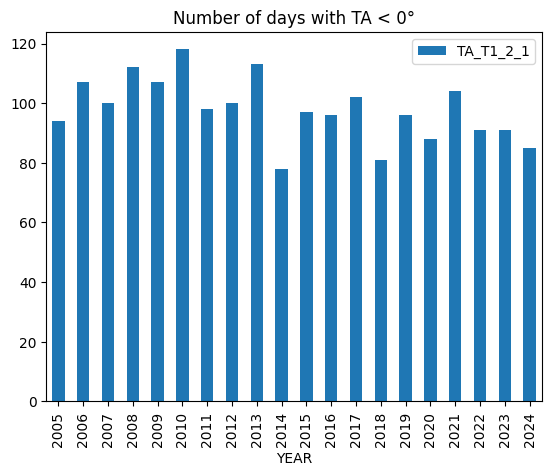

In [24]:
plotdf = df[[varname]].copy()
plotdf = plotdf.resample('D').min()
belowzero = plotdf.loc[plotdf[varname] < 0].copy()
belowzero = belowzero.groupby(belowzero.index.year).count()
belowzero["YEAR"] = belowzero.index
belowzero
belowzero.plot.bar(x="YEAR", y=varname, title="Number of days with TA < 0°");
display(belowzero)
print(f"Average per year: {belowzero[varname].mean()} +/- {belowzero[varname].std():.2f} SD")

## Number of days above 30°C

,TA_T1_2_1,YEAR
TIMESTAMP_MIDDLE,,
2005,8,2005
2006,17,2006
2007,9,2007
2008,12,2008
2009,18,2009
2010,14,2010
2011,10,2011
2012,13,2012
2013,14,2013


Average per year: 16.45 +/- 6.89 SD


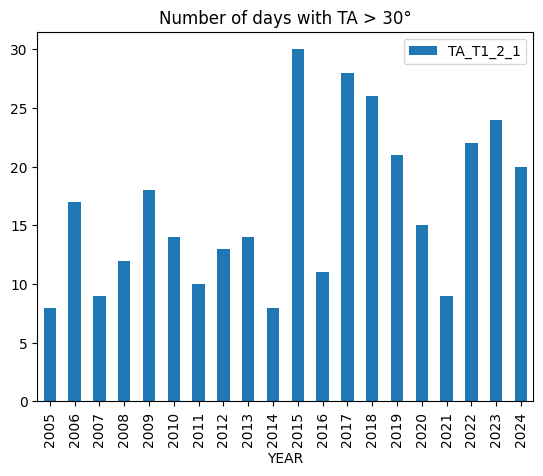

In [25]:
plotdf = df[[varname]].copy()
plotdf = plotdf.resample('D').max()
above = plotdf.loc[plotdf[varname] > 30].copy()
above = above.groupby(above.index.year).count()
above["YEAR"] = above.index
above.plot.bar(x="YEAR", y=varname, title="Number of days with TA > 30°");
display(above)
print(f"Average per year: {above[varname].mean()} +/- {above[varname].std():.2f} SD")

</br>

# Heatmap plots

## Half-hourly

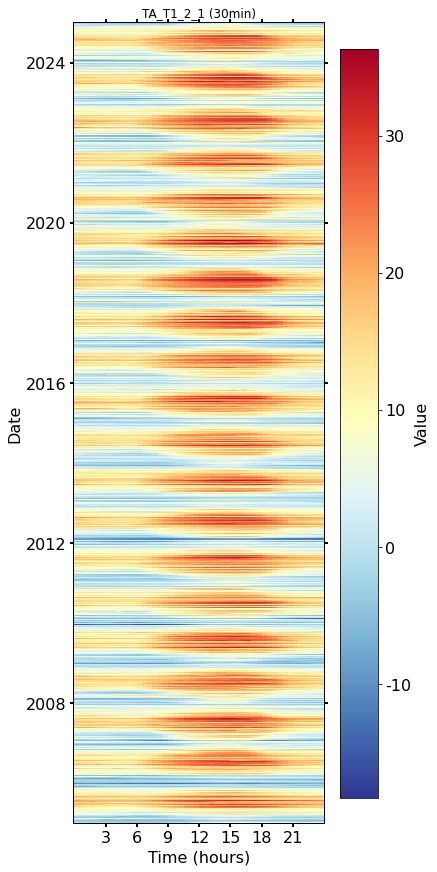

In [8]:
fig, axs = plt.subplots(ncols=1, figsize=(6, 12), dpi=72, layout="constrained")
dv.heatmapdatetime(series=series, ax=axs, cb_digits_after_comma=0).plot()

## Monthly

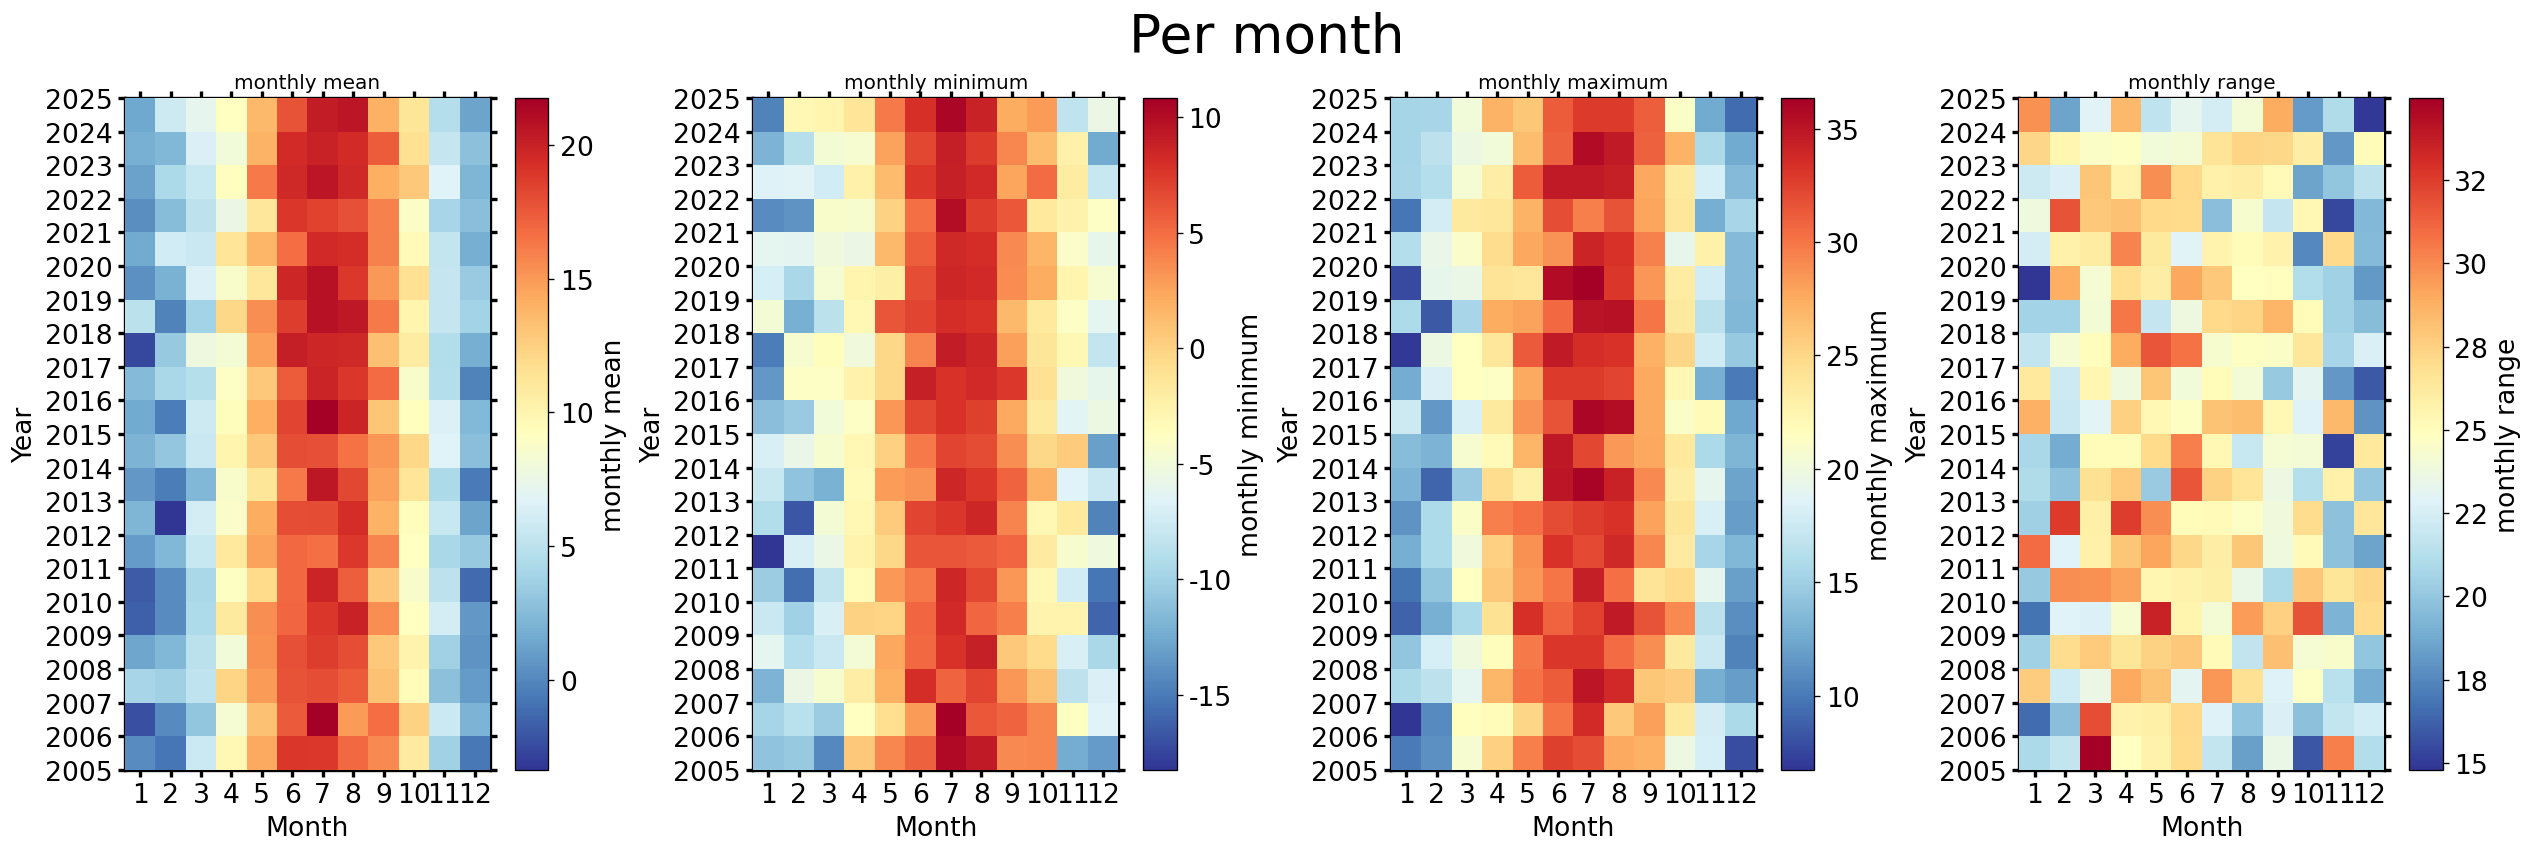

In [15]:
fig, axs = plt.subplots(ncols=4, figsize=(21, 7), dpi=120, layout="constrained")
fig.suptitle(f'Per month', fontsize=32)
dv.heatmapyearmonth(series_monthly=series.resample('M').mean(), title="monthly mean", ax=axs[0], cb_digits_after_comma=0, zlabel="monthly mean").plot()
dv.heatmapyearmonth(series_monthly=series.resample('M').min(), title="monthly minimum", ax=axs[1], cb_digits_after_comma=0, zlabel="monthly minimum").plot()
dv.heatmapyearmonth(series_monthly=series.resample('M').max(), title="monthly maximum", ax=axs[2], cb_digits_after_comma=0, zlabel="monthly maximum").plot()
_range = series.resample('M').max().sub(series.resample('M').min())
dv.heatmapyearmonth(series_monthly=_range, title="monthly range", ax=axs[3], cb_digits_after_comma=0, zlabel="monthly range").plot()

## Monthly ranks

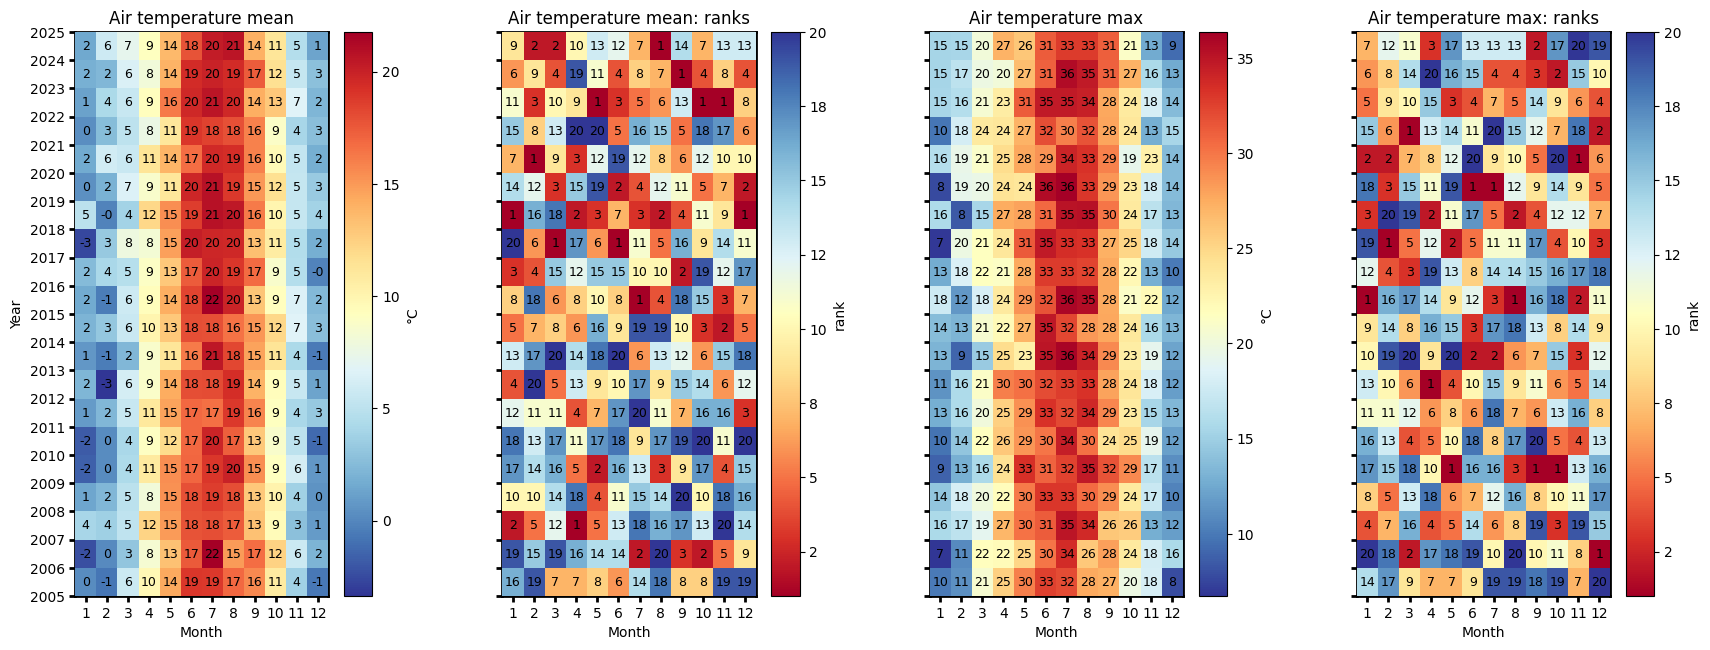

In [18]:
# Figure
fig = plt.figure(facecolor='white', figsize=(17, 6))

# Gridspec for layout
gs = gridspec.GridSpec(1, 4)  # rows, cols
gs.update(wspace=0.35, hspace=0.3, left=0.03, right=0.97, top=0.97, bottom=0.03)
ax_mean = fig.add_subplot(gs[0, 0])
ax_mean_ranks = fig.add_subplot(gs[0, 1])
ax_max = fig.add_subplot(gs[0, 2])
ax_max_ranks = fig.add_subplot(gs[0, 3])
params = {'axlabels_fontsize': 10, 'ticks_labelsize': 10, 'cb_labelsize': 10}
dv.heatmapyearmonth_ranks(ax=ax_mean, series=series, agg='mean', ranks=False, zlabel="°C", cmap="RdYlBu_r", **params).plot()

hm_mean_ranks = dv.heatmapyearmonth_ranks(ax=ax_mean_ranks, series=series, agg='mean', **params)
hm_mean_ranks.plot()

dv.heatmapyearmonth_ranks(ax=ax_max, series=series, agg='max', ranks=False, zlabel="°C", cmap="RdYlBu_r", **params).plot()
dv.heatmapyearmonth_ranks(ax=ax_max_ranks, series=series, agg='max', **params).plot()

ax_mean.set_title("Air temperature mean", color='black')
ax_mean_ranks.set_title("Air temperature mean: ranks", color='black')
ax_max.set_title("Air temperature max", color='black')
ax_max_ranks.set_title("Air temperature max: ranks", color='black')

ax_mean.tick_params(left=True, right=False, top=False, bottom=True,
                    labelleft=True, labelright=False, labeltop=False, labelbottom=True)
ax_mean_ranks.tick_params(left=True, right=False, top=False, bottom=True,
                   labelleft=False, labelright=False, labeltop=False, labelbottom=True)
ax_max.tick_params(left=True, right=False, top=False, bottom=True,
                     labelleft=False, labelright=False, labeltop=False, labelbottom=True)
ax_max_ranks.tick_params(left=True, right=False, top=False, bottom=True,
                     labelleft=False, labelright=False, labeltop=False, labelbottom=True)

ax_mean_ranks.set_ylabel("")
ax_max.set_ylabel("")
ax_max_ranks.set_ylabel("")

fig.show()

### Mean ranks per year

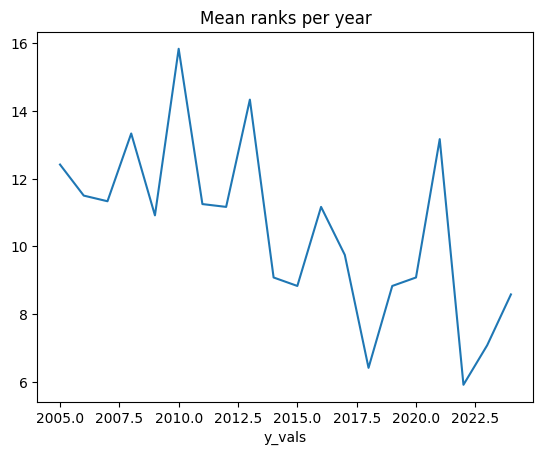

In [19]:
hm_mean_ranks.hm.get_plot_data().mean(axis=1).plot(title="Mean ranks per year");

</br>

# Ridgeline plots

## Yearly

In [ ]:
rp = dv.ridgeline(series=series)
rp.plot(
    how='yearly',
    kd_kwargs=None,  # params from scikit KernelDensity as dict
    xlim=xlim,  # min/max as list
    ylim=[0, 0.07],  # min/max as list
    hspace=-0.8,  # overlap between months
    xlabel=f"{var} ({units})",
    fig_width=5,
    fig_height=9,
    shade_percentile=0.5,
    show_mean_line=False,
    fig_title=f"{var} per year (2005-2024)",
    fig_dpi=72,
    showplot=True,
    ascending=False
)

## Monthly

In [ ]:
rp.plot(
    how='monthly',
    kd_kwargs=None,  # params from scikit KernelDensity as dict
    xlim=xlim,  # min/max as list
    ylim=[0, 0.14],  # min/max as list
    hspace=-0.6,  # overlap between months
    xlabel=f"{var} ({units})",
    fig_width=4.5,
    fig_height=8,
    shade_percentile=0.5,
    show_mean_line=False,
    fig_title=f"{var} per month (2005-2024)",
    fig_dpi=72,
    showplot=True,
    ascending=False
)

## Weekly

In [ ]:
rp.plot(
    how='weekly',
    kd_kwargs=None,  # params from scikit KernelDensity as dict
    xlim=xlim,  # min/max as list
    ylim=[0, 0.15],  # min/max as list
    hspace=-0.6,  # overlap
    xlabel=f"{var} ({units})",
    fig_width=6,
    fig_height=16,
    shade_percentile=0.5,
    show_mean_line=False,
    fig_title=f"{var} per week (2005-2024)",
    fig_dpi=72,
    showplot=True,
    ascending=False
)

## Single years per month

In [ ]:
uniq_years = series.index.year.unique()
for uy in uniq_years:
    series_yr = series.loc[series.index.year == uy].copy()
    rp = dv.ridgeline(series=series_yr)
    rp.plot(
        how='monthly',
        kd_kwargs=None,  # params from scikit KernelDensity as dict
        xlim=xlim,  # min/max as list
        ylim=[0, 0.18],  # min/max as list
        hspace=-0.6,  # overlap
        xlabel=f"{var} ({units})",
        fig_width=6,
        fig_height=7,
        shade_percentile=0.5,
        show_mean_line=False,
        fig_title=f"{var} per month ({uy})",
        fig_dpi=72,
        showplot=True,
        ascending=False
    )

## Single years per week

In [ ]:
uniq_years = series.index.year.unique()
for uy in uniq_years:
    series_yr = series.loc[series.index.year == uy].copy()
    rp = dv.ridgeline(series=series_yr)
    rp.plot(
        how='weekly',
        kd_kwargs=None,  # params from scikit KernelDensity as dict
        xlim=xlim,  # min/max as list
        ylim=[0, 0.3],  # min/max as list
        hspace=-0.8,  # overlap
        xlabel=f"{var} ({units})",
        fig_width=9,
        fig_height=18,
        shade_percentile=0.5,
        show_mean_line=False,
        fig_title=f"{var} per week ({uy})",
        fig_dpi=72,
        showplot=True,
        ascending=False
    )

</br>

# Cumulative plot

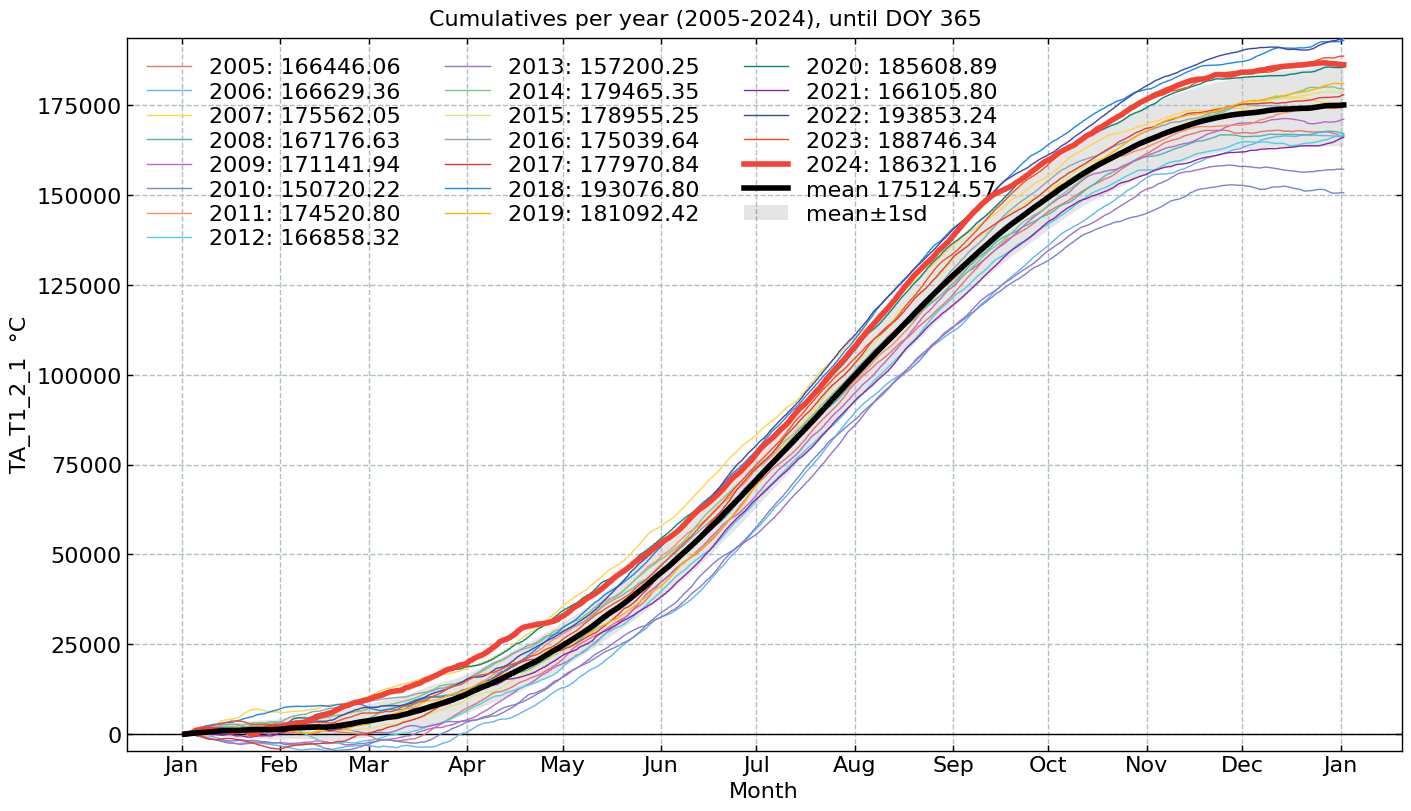

In [34]:
CumulativeYear(
    series=series,
    series_units=units,
    start_year=2005,
    end_year=2024,
    show_reference=True,
    excl_years_from_reference=None,
    highlight_year=2024,
    highlight_year_color='#F44336').plot();

</br>

# Long-term anomalies

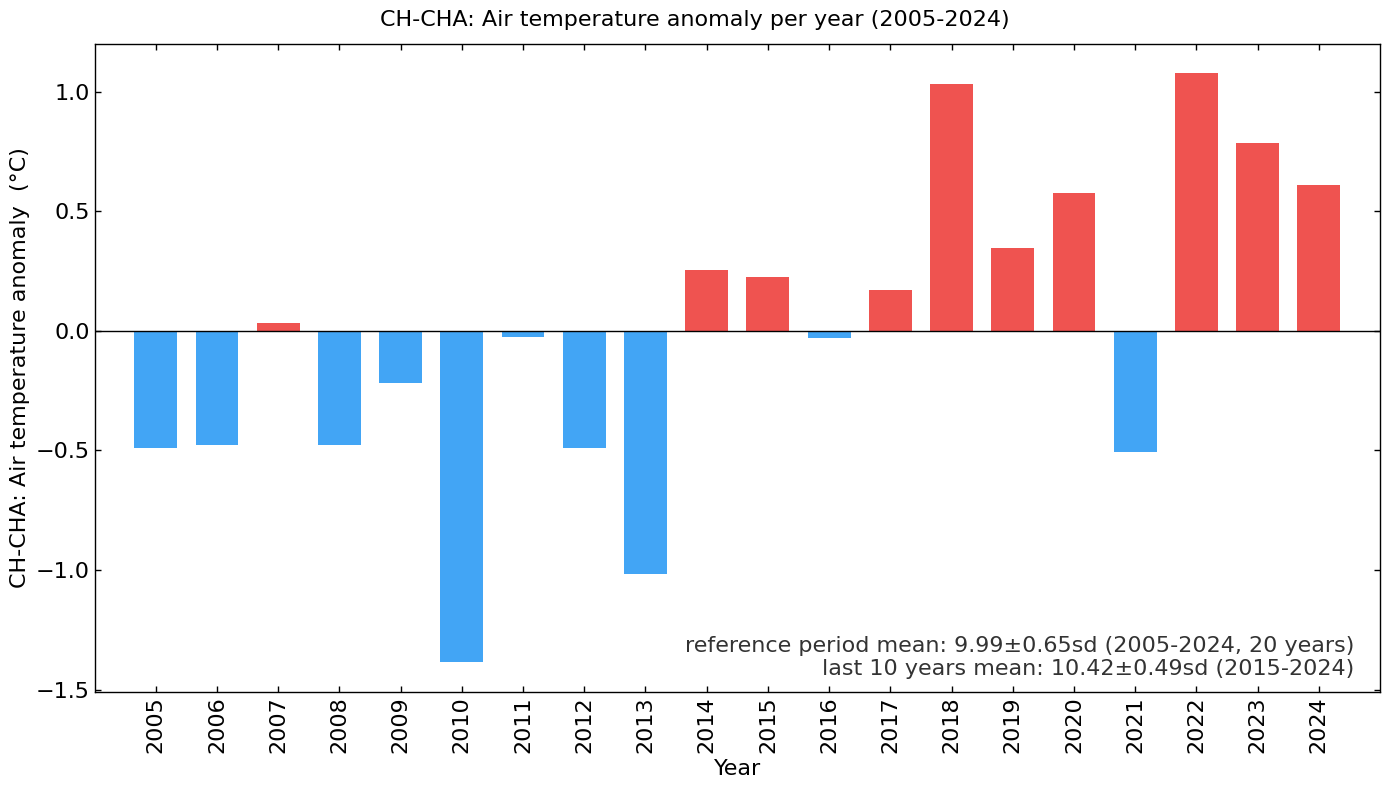

In [38]:
series_yearly_mean = series.resample('YE').mean()
series_yearly_mean.index = series_yearly_mean.index.year
series_label = "CH-CHA: Air temperature"
LongtermAnomaliesYear(series=series_yearly_mean,
                      series_label=series_label,
                      series_units='(°C)',
                      reference_start_year=2005,
                      reference_end_year=2024).plot()

</br>

# End of notebook

In [33]:
dt_string = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
print(f"Finished. {dt_string}")

Finished. 2025-05-14 13:53:30
